---


Nama : Sintia Sari

NIM : 0110222135

Matkul : Machine Learning | Sesi Pagi

Rombel : TI08 - 2022



---


## Latihan 1 : Klasifikasi suhu udara menggunakan KNN (Persepsi Panas dan Dingin)

In [146]:
import pandas as pd
import numpy as np

In [147]:
# Data Set (Training)
data_train = {
    'Temperatur Udara': [10, 25, 15, 20, 18, 20, 22, 24],
    'Kecepatan Angin (km/jam)': [0, 0, 5, 3, 7, 10, 5, 6],
    'Klasifikasi': ['Dingin', 'Panas', 'Dingin', 'Panas', 'Dingin', 'Dingin', 'Panas', 'Panas']
}
df = pd.DataFrame(data_train)

In [148]:
df

,Temperatur Udara,Kecepatan Angin (km/jam),Klasifikasi
0,10,0,Dingin
1,25,0,Panas
2,15,5,Dingin
3,20,3,Panas
4,18,7,Dingin
5,20,10,Dingin
6,22,5,Panas
7,24,6,Panas


In [149]:
# Data Test Baru
X_test_baru = np.array([16, 3]) # Suhu 16°C, Kecepatan Angin 3 km/jam

# Fungsi untuk menghitung Jarak Euclidean
def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

In [150]:
# Hitung nilai min dan max dari data training
temp_min = df['Temperatur Udara'].min()
temp_max = df['Temperatur Udara'].max()
angin_min = df['Kecepatan Angin (km/jam)'].min()
angin_max = df['Kecepatan Angin (km/jam)'].max()

# Normalisasi Min-Max di data training
df['Temperatur_Norm'] = (df['Temperatur Udara'] - temp_min) / (temp_max - temp_min)
df['Angin_Norm'] = (df['Kecepatan Angin (km/jam)'] - angin_min) / (angin_max - angin_min)

# Normalisasi Min-Max pada data test baru menggunakan min dan max dari data training
X_test_baru_norm = np.array([
    (X_test_baru[0] - temp_min) / (temp_max - temp_min),
    (X_test_baru[1] - angin_min) / (angin_max - angin_min)
])

print("Data Training Setelah Normalisasi:")
display(df[['Temperatur_Norm', 'Angin_Norm', 'Klasifikasi']])
print("\nData Test Baru Setelah Normalisasi:")
display(pd.DataFrame([X_test_baru_norm], columns=['Temperatur_Norm', 'Angin_Norm']))

Data Training Setelah Normalisasi:


,Temperatur_Norm,Angin_Norm,Klasifikasi
0,0.000000,0.0,Dingin
1,1.000000,0.0,Panas
2,0.333333,0.5,Dingin
3,0.666667,0.3,Panas
4,0.533333,0.7,Dingin
5,0.666667,1.0,Dingin
6,0.800000,0.5,Panas
7,0.933333,0.6,Panas



Data Test Baru Setelah Normalisasi:


,Temperatur_Norm,Angin_Norm
0,0.4,0.3


In [151]:
# Jumlah tetangga terdekat (k)
k = 3
X_train_norm = df[['Temperatur_Norm', 'Angin_Norm']].values # Fitur ter normalisasi dari data training

# Hitung jarak Euclidean antara data test baru (normalisasi) dan setiap titik data training (normalisasi)
df['Jarak'] = [euclidean_distance(X_test_baru_norm, x) for x in X_train_norm]

# Urutkan berdasarkan jarak dan ambil k baris teratas
df_sorted = df.sort_values(by='Jarak').head(k)

print(f"\n--- {k} Tetangga Terdekat (k={k}) ---")
display(df_sorted[['Temperatur Udara', 'Kecepatan Angin (km/jam)', 'Klasifikasi', 'Jarak']])

# Prediksi klasifikasi berdasarkan mode dari k tetangga terdekat
prediksi_k3 = df_sorted['Klasifikasi'].mode()[0]
print(f"\nPersepsi Marry (Prediksi KNN dengan k={k}) adalah: {prediksi_k3}")


--- 3 Tetangga Terdekat (k=3) ---


,Temperatur Udara,Kecepatan Angin (km/jam),Klasifikasi,Jarak
2,15,5,Dingin,0.210819
3,20,3,Panas,0.266667
4,18,7,Dingin,0.421637



Persepsi Marry (Prediksi KNN dengan k=3) adalah: Dingin


## Latihan 2 : Membuat Confusion Matrix, menghitung Accuracy, Precision, dan Recall.

In [152]:
# DataFrame berdasarkan data yang ada di soal:
data_latihan2 = {
    'Nim': ['TI001', 'TI002', 'TI003', 'TI004', 'TI005', 'TI006', 'TI007', 'TI008', 'TI009', 'TI010'],
    'Hasil Sebenarnya': ['Lulus', 'Lulus', 'Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus'],
    'Hasil Prediksi': ['Lulus', 'Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus', 'Tidak Lulus']
}
df_latihan2 = pd.DataFrame(data_latihan2)

In [153]:
df_latihan2

,Nim,Hasil Sebenarnya,Hasil Prediksi
0,TI001,Lulus,Lulus
1,TI002,Lulus,Lulus
2,TI003,Lulus,Lulus
3,TI004,Lulus,Tidak Lulus
4,TI005,Lulus,Tidak Lulus
5,TI006,Tidak Lulus,Lulus
6,TI007,Tidak Lulus,Tidak Lulus
7,TI008,Tidak Lulus,Tidak Lulus
8,TI009,Tidak Lulus,Tidak Lulus
9,TI010,Tidak Lulus,Tidak Lulus


In [154]:
# Definisikan label aktual (y_true) dan prediksi (y_pred)
y_true = df_latihan2['Hasil Sebenarnya']
y_pred = df_latihan2['Hasil Prediksi']

labels = ['Lulus', 'Tidak Lulus']

print("Data Aktual vs. Prediksi:")
display(df_latihan2[['Hasil Sebenarnya', 'Hasil Prediksi']])

Data Aktual vs. Prediksi:


,Hasil Sebenarnya,Hasil Prediksi
0,Lulus,Lulus
1,Lulus,Lulus
2,Lulus,Lulus
3,Lulus,Tidak Lulus
4,Lulus,Tidak Lulus
5,Tidak Lulus,Lulus
6,Tidak Lulus,Tidak Lulus
7,Tidak Lulus,Tidak Lulus
8,Tidak Lulus,Tidak Lulus
9,Tidak Lulus,Tidak Lulus


In [155]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Hitung Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)

print("\nConfusion Matrix:")
display(cm_df)


Confusion Matrix:


,Lulus,Tidak Lulus
Lulus,3,2
Tidak Lulus,1,4


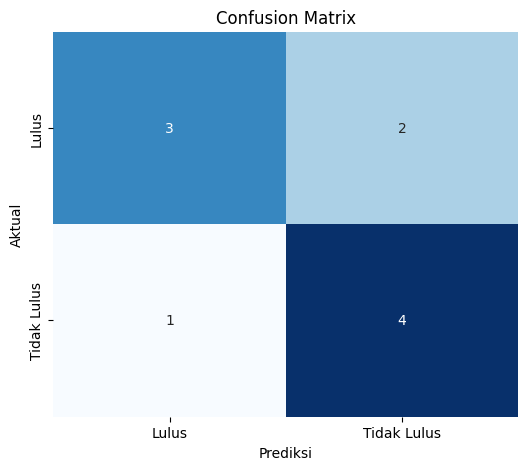

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualisasi Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [157]:
# Hitung Akurasi
accuracy = accuracy_score(y_true, y_pred)

# Hitung Presisi (untuk kelas positif: 'Lulus')
precision = precision_score(y_true, y_pred, pos_label='Lulus')

# Hitung Recall (untuk kelas positif: 'Lulus')
recall = recall_score(y_true, y_pred, pos_label='Lulus')

# Buat DataFrame untuk metrik evaluasi
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall'],
    'Value': [f'{accuracy:.2f}', f'{precision:.2f}', f'{recall:.2f}']
})

print("\nHasil Perhitungan Metrik:")
display(metrics_df)


Hasil Perhitungan Metrik:


,Metric,Value
0,Accuracy,0.70
1,Precision,0.75
2,Recall,0.60


## Latihan 3 : Studi kasus Prediksi Cuaca menggunakan algoritma KNN

In [158]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [159]:
# Masukkan data ke dalam DataFrame
data_latihan3 = {
    'Temperature': [14.0, 39.0, 30.0, 38.0, 27.0, 32.0, -2.0, 3.0, 3.0, 28.0],
    'Humidity': [73, 96, 64, 83, 74, 55, 97, 85, 83, 74],
    'Wind Speed': [9.5, 8.5, 7.0, 1.5, 17.0, 3.5, 8.0, 6.0, 6.0, 8.5],
    'Precipitation (%)': [82.0, 71.0, 16.0, 82.0, 66.0, 26.0, 86.0, 96.0, 66.0, 107.0],
    'Cloud Cover': ['partly cloudy', 'partly cloudy', 'clear', 'clear', 'overcast', 'overcast', 'overcast', 'partly cloudy', 'overcast', 'clear'],
    'Atmospheric Pressure': [1010.82, 1011.43, 1018.72, 1026.25, 990.67, 1010.03, 990.87, 984.46, 999.44, 1012.13],
    'UV Index': [2, 7, 5, 7, 1, 2, 1, 1, 0, 8],
    'Season': ['Winter', 'Spring', 'Spring', 'Spring', 'Winter', 'Summer', 'Winter', 'Winter', 'Winter', 'Winter'],
    'Visibility (km)': [3.5, 10.0, 5.5, 1.5, 2.5, 5.0, 4.0, 3.5, 1.0, 7.5],
    'Location': ['inland', 'inland', 'mountain', 'coastal', 'mountain', 'inland', 'inland', 'inland', 'mountain', 'coastal'],
    'Weather Type': ['Rainy', 'Cloudy', 'Sunny', 'Sunny', 'Rainy', 'Cloudy', 'Snowy', 'Snowy', 'Snowy', 'Sunny']
}
df_latihan3 = pd.DataFrame(data_latihan3)

In [160]:
df_latihan3

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.5,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [161]:
# Definisikan Fitur (X) dan Target (y)
X = df_latihan3.drop('Weather Type', axis=1)
y = df_latihan3['Weather Type']

In [162]:
# Kategorisasi Jenis Fitur
numerical_features = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
categorical_features = ['Cloud Cover', 'Season', 'Location']

In [163]:
# Buat Pipeline untuk Pre-processing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Biarkan fitur lain (jika ada) apa adanya
)

print("Pre-processing: Standard Scaling untuk Numerik dan One-Hot Encoding untuk Kategorikal.")

Pre-processing: Standard Scaling untuk Numerik dan One-Hot Encoding untuk Kategorikal.


In [164]:
# Split Data Training dan Testing (70:30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [165]:
# Pipeline Model
k_value = 3
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=k_value))
])

In [166]:
# Latih Model
knn_pipeline.fit(X_train, y_train)

# Prediksi pada Data Test
y_pred = knn_pipeline.predict(X_test)

print(f"\nModel KNN (k={k_value}) telah dilatih.")


Model KNN (k=3) telah dilatih.


In [167]:
# Evaluasi Performa
accuracy = accuracy_score(y_test, y_pred)

# Dapatkan semua label unik yang muncul di data test dan prediksi
unique_labels = np.unique(np.concatenate((y_test, y_pred)))

# Hitung Confusion Matrix menggunakan scikit-learn, pastikan urutan label konsisten
cm = confusion_matrix(y_test, y_pred, labels=unique_labels)

report = classification_report(y_test, y_pred, zero_division=0) # zero_division=0 agar tidak error jika ada kelas yang tidak diprediksi

print("\nHasil Evaluasi Model KNN")
print(f"Accuracy Model pada Data Test (k={k_value}): {accuracy * 100:.2f}%\n")
print("Laporan Klasifikasi:")
print(report)


Hasil Evaluasi Model KNN
Accuracy Model pada Data Test (k=3): 33.33%

Laporan Klasifikasi:
              precision    recall  f1-score   support

      Cloudy       0.00      0.00      0.00         2
       Rainy       0.00      0.00      0.00         0
       Snowy       1.00      1.00      1.00         1
       Sunny       0.00      0.00      0.00         0

    accuracy                           0.33         3
   macro avg       0.25      0.25      0.25         3
weighted avg       0.33      0.33      0.33         3



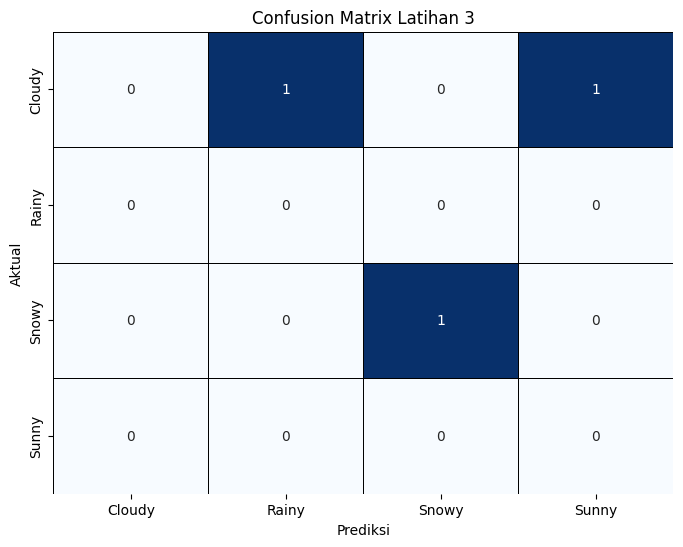

In [168]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            linewidths=.5, linecolor='black',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix Latihan 3')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()